═══════════════════════════════════════════════════════════════════════════
📌 Notebook 6: Análise e Interpretação dos Clusters
═══════════════════════════════════════════════════════════════════════════

Neste notebook vamos:
✅ Analisar o perfil de cada cluster
✅ Nomear os clusters de forma interpretável
✅ Identificar municípios representativos
✅ Criar visualizações comparativas
✅ Gerar insights acionáveis
✅ Exportar resultados finais

⏱️ Tempo estimado: 40-50 minutos

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Setup
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import joblib
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("📊 ANÁLISE E INTERPRETAÇÃO DOS CLUSTERS")
print("="*80)
print("✅ Bibliotecas carregadas!")
print()


📊 ANÁLISE E INTERPRETAÇÃO DOS CLUSTERS
✅ Bibliotecas carregadas!



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados e modelos
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import pandas as pd
import joblib

print("="*80)
print("📂 CARREGANDO DADOS E MODELOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Paths
data_path = base_path / 'data/processed/municipios_com_clusters.csv'
features_path = base_path / 'outputs/results/features_selecionadas.json'
model_path = base_path / 'outputs/results/kmeans_model.pkl'
metadata_path = base_path / 'outputs/results/model_metadata.json'

# Carregar dataset com clusters
df = pd.read_csv(data_path)
print(f"✅ Dataset carregado: {len(df):,} municípios")

# Carregar features selecionadas
with open(features_path, 'r', encoding='utf-8') as f:
    features_metadata = json.load(f)
    selected_features = features_metadata['features_selecionadas']

print(f"✅ Features carregadas: {len(selected_features)}")

# Carregar modelo
kmeans = joblib.load(model_path)
K_CLUSTERS = int(kmeans.n_clusters)
print(f"✅ Modelo KMeans carregado: {K_CLUSTERS} clusters")

# Carregar metadados
with open(metadata_path, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

print()
print("📊 INFORMAÇÕES DO MODELO:")
print(f"   K: {K_CLUSTERS}")
print(f"   Silhouette Score: {metadata['metricas']['silhouette']:.4f}")
print(f"   Qualidade: {metadata['metricas']['qualidade']}")
print()


📂 CARREGANDO DADOS E MODELOS

✅ Dataset carregado: 5,204 municípios
✅ Features carregadas: 7
✅ Modelo KMeans carregado: 4 clusters

📊 INFORMAÇÕES DO MODELO:
   K: 4
   Silhouette Score: 0.1513
   Qualidade: Fraco



In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: Calcular estatísticas por cluster (valores originais)
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 PERFIL ESTATÍSTICO DE CADA CLUSTER")
print("="*80)
print()

print("💡 METODOLOGIA:")
print("   Vamos analisar as características usando os valores ORIGINAIS")
print("   (não normalizados) para facilitar a interpretação.")
print()

# Identificar colunas originais (terminam com _original)
original_cols = [col for col in df.columns if col.endswith('_original')]

# Criar mapeamento de nomes
original_names = {col: col.replace('_original', '') for col in original_cols}

# Adicionar outras colunas úteis
analysis_cols = original_cols + ['nome_municipio', 'uf', 'regiao', 'cluster']

# Análise por cluster
cluster_profiles = []

print("🔄 Calculando estatísticas para cada cluster...")
print()

for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    
    profile = {
        'Cluster': cluster_id,
        'N_Municipios': len(cluster_data),
        'Percentual': (len(cluster_data) / len(df)) * 100
    }
    
    # Estatísticas para cada variável original
    for col in original_cols:
        var_name = original_names[col]
        profile[f'{var_name}_mean'] = cluster_data[col].mean()
        profile[f'{var_name}_median'] = cluster_data[col].median()
        profile[f'{var_name}_std'] = cluster_data[col].std()
        profile[f'{var_name}_min'] = cluster_data[col].min()
        profile[f'{var_name}_max'] = cluster_data[col].max()
    
    cluster_profiles.append(profile)

profiles_df = pd.DataFrame(cluster_profiles)

print("✅ Estatísticas calculadas!")
print()

# Exibir resumo básico
print("📋 RESUMO BÁSICO DOS CLUSTERS:")
print()
summary_cols = ['Cluster', 'N_Municipios', 'Percentual']
display(profiles_df[summary_cols])

print()

📊 PERFIL ESTATÍSTICO DE CADA CLUSTER

💡 METODOLOGIA:
   Vamos analisar as características usando os valores ORIGINAIS
   (não normalizados) para facilitar a interpretação.

🔄 Calculando estatísticas para cada cluster...

✅ Estatísticas calculadas!

📋 RESUMO BÁSICO DOS CLUSTERS:



,Cluster,N_Municipios,Percentual
0,0,2780,53.42
1,1,1220,23.44
2,2,663,12.74
3,3,541,10.40


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: Criar perfis detalhados por cluster
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🔍 PERFIS DETALHADOS POR CLUSTER")
print("="*80)
print()

# Função para formatar números grandes
def format_number(n):
    if n >= 1_000_000:
        return f"{n/1_000_000:.1f}M"
    elif n >= 1_000:
        return f"{n/1_000:.1f}K"
    else:
        return f"{n:.0f}"

# Analisar cada cluster detalhadamente
for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    
    print("="*70)
    print(f"CLUSTER {cluster_id}")
    print("="*70)
    print()
    
    print(f"📊 TAMANHO:")
    print(f"   {len(cluster_data):,} municípios ({len(cluster_data)/len(df)*100:.1f}% do total)")
    print()
    
    # Distribuição geográfica
    print("🗺️  DISTRIBUIÇÃO GEOGRÁFICA:")
    print()
    print("   Por Região:")
    regiao_dist = cluster_data['regiao'].value_counts()
    for regiao, count in regiao_dist.items():
        pct = (count / len(cluster_data)) * 100
        bar = '█' * int(pct / 5)
        print(f"      {regiao:15s}: {count:4,} ({pct:5.1f}%) {bar}")
    
    print()
    print("   Estados com mais municípios:")
    top_estados = cluster_data['uf'].value_counts().head(5)
    for uf, count in top_estados.items():
        print(f"      {uf}: {count:,} municípios")
    
    print()
    
    # Características socioeconômicas (médias)
    print("💰 PERFIL SOCIOECONÔMICO (MÉDIAS):")
    print()
    
    if 'populacao_original' in cluster_data.columns:
        pop_mean = cluster_data['populacao_original'].mean()
        print(f"   População média: {format_number(pop_mean)} habitantes")
    
    if 'pib_per_capita_original' in cluster_data.columns:
        pib_pc = cluster_data['pib_per_capita_original'].mean()
        print(f"   PIB per capita médio: R$ {pib_pc:,.2f}")
    
    if 'densidade_original' in cluster_data.columns:
        densidade = cluster_data['densidade_original'].mean()
        print(f"   Densidade média: {densidade:.1f} hab/km²")
    
    if 'taxa_alfabetizacao_original' in cluster_data.columns:
        alfab = cluster_data['taxa_alfabetizacao_original'].mean()
        print(f"   Taxa alfabetização: {alfab:.1f}%")
    
    if 'mortalidade_infantil_original' in cluster_data.columns:
        mort = cluster_data['mortalidade_infantil_original'].mean()
        print(f"   Mortalidade infantil: {mort:.1f} por mil")
    
    if 'esgoto_adequado_original' in cluster_data.columns:
        esgoto = cluster_data['esgoto_adequado_original'].mean()
        print(f"   Esgoto adequado: {esgoto:.1f}%")
    
    print()
    
    # Municípios exemplares
    print("🏙️  MUNICÍPIOS EXEMPLARES (mais próximos do centróide):")
    print()
    
    # Calcular distância ao centróide
    centroid = kmeans.cluster_centers_[cluster_id]
    X_cluster = df[df['cluster'] == cluster_id][selected_features].values
    
    # Distâncias euclidianas
    distances = np.sqrt(((X_cluster - centroid) ** 2).sum(axis=1))
    
    # Top 5 mais próximos
    closest_indices = distances.argsort()[:5]
    closest_cities = cluster_data.iloc[closest_indices][['nome_municipio', 'uf']]
    
    for idx, (_, row) in enumerate(closest_cities.iterrows(), 1):
        print(f"      {idx}. {row['nome_municipio']} - {row['uf']}")
    
    print()
    print()

🔍 PERFIS DETALHADOS POR CLUSTER

CLUSTER 0

📊 TAMANHO:
   2,780 municípios (53.4% do total)

🗺️  DISTRIBUIÇÃO GEOGRÁFICA:

   Por Região:
      Nordeste       : 1,075 ( 38.7%) ███████
      Sudeste        :  813 ( 29.2%) █████
      Sul            :  448 ( 16.1%) ███
      Norte          :  254 (  9.1%) █
      Centro-Oeste   :  190 (  6.8%) █

   Estados com mais municípios:
      MG: 497 municípios
      BA: 297 municípios
      SP: 249 municípios
      PR: 212 municípios
      PI: 145 municípios

💰 PERFIL SOCIOECONÔMICO (MÉDIAS):

   População média: 12.9K habitantes
   PIB per capita médio: R$ 21,127.16
   Densidade média: 27.4 hab/km²
   Taxa alfabetização: 85.1%
   Mortalidade infantil: 19.8 por mil
   Esgoto adequado: 60.4%

🏙️  MUNICÍPIOS EXEMPLARES (mais próximos do centróide):

      1. Santa Leopoldina - ES
      2. Pureza - RN
      3. Uruana - GO
      4. Reginópolis - SP
      5. Rincão - SP


CLUSTER 1

📊 TAMANHO:
   1,220 municípios (23.4% do total)

🗺️  DISTRIBUIÇÃO GE

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 5: Nomear clusters de forma interpretável
# ═══════════════════════════════════════════════════════════════════════════

print("="*80)
print("🏷️  NOMEAÇÃO DOS CLUSTERS")
print("="*80)
print()

print("💡 Vamos atribuir nomes descritivos baseados nas características")
print("   de cada cluster para facilitar a interpretação.")
print()

def name_cluster(cluster_id, profiles_df, df):
    """Atribui nome interpretável ao cluster"""
    
    profile = profiles_df[profiles_df['Cluster'] == cluster_id].iloc[0]
    cluster_data = df[df['cluster'] == cluster_id]
    
    # Extrair características principais
    pop_mean = profile.get('populacao_mean', 0)
    pib_pc = profile.get('pib_per_capita_mean', 0)
    densidade = profile.get('densidade_mean', 0)
    alfab = profile.get('taxa_alfabetizacao_mean', 0)
    esgoto = profile.get('esgoto_adequado_mean', 0)
    
    # ===================================================================
    # NOVA LÓGICA: Diferenciar clusters 2 e 3 pelo PIB per capita
    # ===================================================================
    
    # Cidades grandes
    if pop_mean > 100_000:
        if densidade > 100:
            return "Cidades Regionais Urbanizadas"
        else:
            return "Cidades Médias"
    
    # Municípios pequenos
    elif pop_mean < 15_000:
        # Diferenciar pelo PIB per capita
        if pib_pc > 50_000:
            # PIB MUITO alto = Agronegócio/Mineração
            return "Municípios de Agronegócio Próspero"
        elif pib_pc > 28_000:
            # PIB moderadamente alto
            if pop_mean < 5_000:
                return "Pequenos Municípios com Boa Infraestrutura"
            else:
                return "Municípios Rurais Desenvolvidos"
        else:
            # PIB baixo
            return "Municípios Rurais em Desenvolvimento"
    
    # Municípios médios
    else:
        if pib_pc > 30_000:
            return "Municípios de Porte Médio Desenvolvidos"
        else:
            return "Municípios de Porte Médio"

# Atribuir nomes
cluster_names = {}
print("🔄 Atribuindo nomes aos clusters...")
print()

for cluster_id in range(K_CLUSTERS):
    name = name_cluster(cluster_id, profiles_df, df)
    cluster_names[cluster_id] = name
    print(f"   Cluster {cluster_id}: {name}")

print()

# Adicionar nomes ao DataFrame
df['cluster_nome'] = df['cluster'].map(cluster_names)
profiles_df['Nome'] = profiles_df['Cluster'].map(cluster_names)

# Reorganizar colunas
cols = ['Cluster', 'Nome', 'N_Municipios', 'Percentual'] + [
    col for col in profiles_df.columns 
    if col not in ['Cluster', 'Nome', 'N_Municipios', 'Percentual']
]
profiles_df = profiles_df[cols]

print("✅ Nomes atribuídos!")
print()

🏷️  NOMEAÇÃO DOS CLUSTERS

💡 Vamos atribuir nomes descritivos baseados nas características
   de cada cluster para facilitar a interpretação.

🔄 Atribuindo nomes aos clusters...

   Cluster 0: Municípios Rurais em Desenvolvimento
   Cluster 1: Municípios de Porte Médio Desenvolvidos
   Cluster 2: Pequenos Municípios com Boa Infraestrutura
   Cluster 3: Municípios de Agronegócio Próspero

✅ Nomes atribuídos!



In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: Visualizações comparativas
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("="*80)
print("📊 VISUALIZAÇÕES COMPARATIVAS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Preparar dados para visualização
comparison_data = []

for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    
    comparison_data.append({
        'Cluster': cluster_names[cluster_id],
        'Cluster_ID': cluster_id,
        'Municipios': len(cluster_data),
        'Pop_Media': cluster_data['populacao_original'].mean() if 'populacao_original' in cluster_data.columns else 0,
        'PIB_PC': cluster_data['pib_per_capita_original'].mean() if 'pib_per_capita_original' in cluster_data.columns else 0,
        'Densidade': cluster_data['densidade_original'].mean() if 'densidade_original' in cluster_data.columns else 0,
        'Alfabetizacao': cluster_data['taxa_alfabetizacao_original'].mean() if 'taxa_alfabetizacao_original' in cluster_data.columns else 0,
        'Esgoto': cluster_data['esgoto_adequado_original'].mean() if 'esgoto_adequado_original' in cluster_data.columns else 0,
        'Mortalidade': cluster_data['mortalidade_infantil_original'].mean() if 'mortalidade_infantil_original' in cluster_data.columns else 0
    })

comp_df = pd.DataFrame(comparison_data)

# 1. Gráfico de barras - Comparação de características
print("🎨 Criando gráficos comparativos...")
print()

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        'População Média',
        'PIB per Capita Médio',
        'Densidade Média',
        'Taxa Alfabetização',
        'Esgoto Adequado',
        'Mortalidade Infantil'
    ),
    vertical_spacing=0.12,
    horizontal_spacing=0.1
)

# População
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['Pop_Media'], 
           marker_color='skyblue', name='População'),
    row=1, col=1
)

# PIB per capita
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['PIB_PC'], 
           marker_color='lightgreen', name='PIB PC'),
    row=1, col=2
)

# Densidade
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['Densidade'], 
           marker_color='lightcoral', name='Densidade'),
    row=1, col=3
)

# Alfabetização
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['Alfabetizacao'], 
           marker_color='plum', name='Alfabetização'),
    row=2, col=1
)

# Esgoto
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['Esgoto'], 
           marker_color='gold', name='Esgoto'),
    row=2, col=2
)

# Mortalidade
fig.add_trace(
    go.Bar(x=comp_df['Cluster'], y=comp_df['Mortalidade'], 
           marker_color='salmon', name='Mortalidade'),
    row=2, col=3
)

# Atualizar layout
fig.update_xaxes(tickangle=45)
fig.update_layout(
    title_text='Comparação de Características entre Clusters',
    showlegend=False,
    height=800,
    template='plotly_white'
)

output_html_1 = output_dir / '20_comparacao_clusters.html'
fig.write_html(output_html_1)
print(f"✅ Gráfico salvo: {output_html_1}")
fig.show()

# 2. Radar chart - Perfil multidimensional
print()
print("🎨 Criando radar chart...")
print()

# Normalizar dados para radar (0-100)
radar_data = comp_df.copy()
for col in ['Pop_Media', 'PIB_PC', 'Densidade', 'Alfabetizacao', 'Esgoto']:
    if col in radar_data.columns:
        min_val = radar_data[col].min()
        max_val = radar_data[col].max()
        if max_val > min_val:
            radar_data[f'{col}_norm'] = ((radar_data[col] - min_val) / (max_val - min_val)) * 100

# Mortalidade: inverter (menor é melhor)
if 'Mortalidade' in radar_data.columns:
    min_val = radar_data['Mortalidade'].min()
    max_val = radar_data['Mortalidade'].max()
    if max_val > min_val:
        radar_data['Mortalidade_norm'] = (1 - (radar_data['Mortalidade'] - min_val) / (max_val - min_val)) * 100

# Criar radar chart
fig = go.Figure()

categories = ['População', 'PIB PC', 'Densidade', 'Alfabetização', 'Esgoto', 'Saúde']

for idx, row in radar_data.iterrows():
    values = [
        row.get('Pop_Media_norm', 0),
        row.get('PIB_PC_norm', 0),
        row.get('Densidade_norm', 0),
        row.get('Alfabetizacao_norm', 0),
        row.get('Esgoto_norm', 0),
        row.get('Mortalidade_norm', 0)
    ]
    
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=categories,
        fill='toself',
        name=row['Cluster']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    showlegend=True,
    title='Perfil Multidimensional dos Clusters (Normalizado 0-100)',
    height=700,
    template='plotly_white'
)

output_html_2 = output_dir / '21_radar_clusters.html'
fig.write_html(output_html_2)
print(f"✅ Gráfico salvo: {output_html_2}")
fig.show()


📊 VISUALIZAÇÕES COMPARATIVAS

🎨 Criando gráficos comparativos...

✅ Gráfico salvo: ..\outputs\figures\20_comparacao_clusters.html



🎨 Criando radar chart...

✅ Gráfico salvo: ..\outputs\figures\21_radar_clusters.html


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: Top municípios por cluster
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 TOP MUNICÍPIOS POR CLUSTER")
print("="*80)
print()

print("💡 Identificando os maiores municípios de cada cluster")
print("   (por população)")
print()

for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    cluster_name = cluster_names[cluster_id]
    
    print(f"{'='*70}")
    print(f"{cluster_name} (Cluster {cluster_id})")
    print(f"{'='*70}")
    print()
    
    # Top 10 por população
    if 'populacao_original' in cluster_data.columns:
        top_10 = cluster_data.nlargest(10, 'populacao_original')[
            ['nome_municipio', 'uf', 'populacao_original', 'pib_per_capita_original']
        ].copy()
        
        top_10.columns = ['Município', 'UF', 'População', 'PIB per Capita']
        
        print("📊 Top 10 por População:")
        print()
        display(top_10.reset_index(drop=True))
    
    print()


🏆 TOP MUNICÍPIOS POR CLUSTER

💡 Identificando os maiores municípios de cada cluster
   (por população)

Municípios Rurais em Desenvolvimento (Cluster 0)

📊 Top 10 por População:



,Município,UF,População,PIB per Capita
0,Paragominas,PA,113498,37702.03
1,Corumbá,MS,98751,38958.24
2,Cáceres,MT,91767,24674.43
3,Tefé,AM,80137,13706.43
4,Casa Nova,BA,76131,11491.76
5,Alenquer,PA,75882,9815.38
6,Campo Formoso,BA,75112,27587.08
7,Barra do Garças,MT,73878,34908.69
8,Coari,AM,73576,45943.31
9,Portel,PA,67580,13981.95



Municípios de Porte Médio Desenvolvidos (Cluster 1)

📊 Top 10 por População:



,Município,UF,População,PIB per Capita
0,Montes Claros,MG,437601,24678.84
1,Anápolis,GO,420300,42325.66
2,Petrolina,PE,418444,19104.21
3,Caruaru,PE,405408,21369.89
4,Vitória da Conquista,BA,396613,20720.61
5,Bauru,SP,392947,42553.75
6,Rio Branco,AC,389001,28163.62
7,Blumenau,SC,385558,53375.86
8,Caucaia,CE,378406,27543.70
9,Cariacica,ES,376200,36413.87



Pequenos Municípios com Boa Infraestrutura (Cluster 2)

📊 Top 10 por População:



,Município,UF,População,PIB per Capita
0,Tamarana,PR,10540,37151.90
1,Praia Norte,TO,9552,9750.73
2,Colméia,TO,9155,19966.79
3,Queluz,SP,9074,42817.17
4,Januário Cicco,RN,8843,9600.70
5,Tomazina,PR,8523,38033.09
6,Jauru,MT,7881,44254.16
7,Serrania,MG,7811,20699.01
8,Cordeiros,BA,7748,9114.09
9,Santa Terezinha,MT,7737,38845.68



Municípios de Agronegócio Próspero (Cluster 3)

📊 Top 10 por População:



,Município,UF,População,PIB per Capita
0,Três Lagoas,MS,143523,81553.08
1,Sorriso,MT,124665,100446.01
2,Catalão,GO,122760,80782.75
3,Nova Lima,MG,120959,173949.57
4,Itabira,MG,118053,126820.58
5,Ipojuca,PE,106539,140130.34
6,Paracatu,MG,99005,72710.98
7,Goiana,PE,85497,124717.41
8,Vinhedo,SP,79089,158781.99
9,Ouro Preto,MG,77914,122170.56


🗺️  DISTRIBUIÇÃO GEOGRÁFICA DOS CLUSTERS

📊 DISTRIBUIÇÃO: REGIÃO x CLUSTER



cluster_nome,Municípios Rurais em Desenvolvimento,Municípios de Agronegócio Próspero,Municípios de Porte Médio Desenvolvidos,Pequenos Municípios com Boa Infraestrutura,Total
regiao,,,,,
Centro-Oeste,190,122,43,69,424
Nordeste,1075,35,460,114,1684
Norte,254,24,55,58,391
Sudeste,813,120,417,214,1564
Sul,448,240,245,208,1141
Total,2780,541,1220,663,5204



🎨 Criando heatmap de distribuição geográfica...

✅ Gráfico salvo: ..\outputs\figures\22_distribuicao_geografica.png


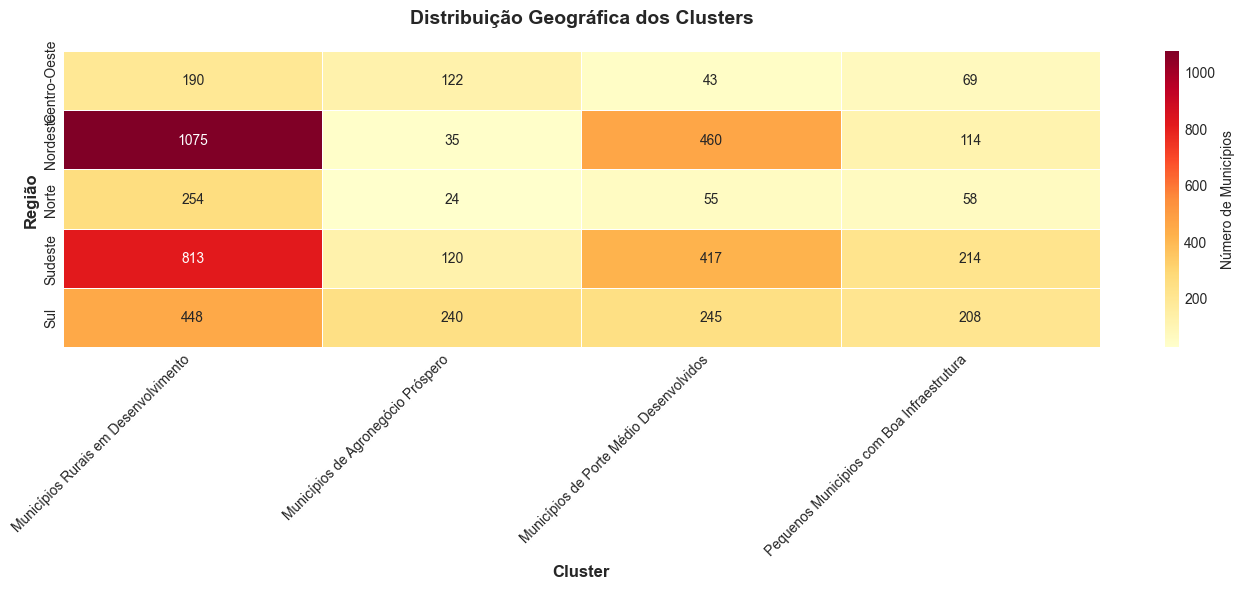

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 8: Matriz de confusão geográfica
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("="*80)
print("🗺️  DISTRIBUIÇÃO GEOGRÁFICA DOS CLUSTERS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída das figuras
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Criar tabela cruzada: Região x Cluster
geo_dist = pd.crosstab(
    df['regiao'],
    df['cluster_nome'],
    margins=True,
    margins_name='Total'
)

print("📊 DISTRIBUIÇÃO: REGIÃO x CLUSTER")
print()
display(geo_dist)

# Visualização: Heatmap
print()
print("🎨 Criando heatmap de distribuição geográfica...")
print()

# Remover linha/coluna de total para o heatmap
geo_dist_plot = pd.crosstab(df['regiao'], df['cluster_nome'])

plt.figure(figsize=(14, 6))
sns.heatmap(
    geo_dist_plot,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Número de Municípios'},
    linewidths=0.5
)
plt.title('Distribuição Geográfica dos Clusters', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Região', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

output_file = output_dir / '22_distribuicao_geografica.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 9: Insights e recomendações
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("💡 INSIGHTS E RECOMENDAÇÕES")
print("="*80)
print()

insights = []

for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    cluster_name = cluster_names[cluster_id]
    profile = profiles_df[profiles_df['Cluster'] == cluster_id].iloc[0]
    
    print(f"{'='*70}")
    print(f"{cluster_name}")
    print(f"{'='*70}")
    print()
    
    # Características principais
    pop_mean = profile.get('populacao_mean', 0)
    pib_pc = profile.get('pib_per_capita_mean', 0)
    densidade = profile.get('densidade_mean', 0)
    
    print("📊 CARACTERIZAÇÃO:")
    print(f"   • {len(cluster_data):,} municípios ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"   • População média: {format_number(pop_mean)}")
    print(f"   • PIB per capita: R$ {pib_pc:,.2f}")
    print(f"   • Densidade: {densidade:.1f} hab/km²")
    print()
    
    # Gerar insights específicos
    print("💼 OPORTUNIDADES DE NEGÓCIO:")
    print()
    
    if "Metrópoles" in cluster_name or "Grandes Centros" in cluster_name:
        print("   ✅ Mercado consolidado e diversificado")
        print("   ✅ Alta capacidade de consumo")
        print("   ✅ Infraestrutura desenvolvida")
        print("   ⚠️  Alta competição")
        print("   💡 Recomendação: Produtos/serviços premium, inovação")
        
    elif "Médias" in cluster_name and "Prósperas" in cluster_name:
        print("   ✅ Mercado em crescimento")
        print("   ✅ Boa capacidade de consumo")
        print("   ✅ Menor competição que grandes centros")
        print("   💡 Recomendação: Expansão regional, varejo especializado")
        
    elif "Regionais" in cluster_name:
        print("   ✅ Polos regionais com influência em municípios vizinhos")
        print("   ✅ Oportunidades em serviços e comércio")
        print("   💡 Recomendação: Hub de distribuição, serviços regionais")
        
    elif "Rurais Desenvolvidos" in cluster_name:
        print("   ✅ Alto PIB (geralmente agronegócio)")
        print("   ✅ Renda concentrada")
        print("   💡 Recomendação: Insumos agrícolas, maquinário, serviços especializados")
        
    else:
        print("   ✅ Grande número de municípios")
        print("   ✅ Oportunidades em produtos básicos")
        print("   💡 Recomendação: Escala, produtos essenciais, preço competitivo")
    
    print()
    
    print("🚚 LOGÍSTICA E DISTRIBUIÇÃO:")
    print()
    
    # Distribuição geográfica
    regioes = cluster_data['regiao'].value_counts()
    regiao_principal = regioes.index[0]
    pct_regiao = (regioes.iloc[0] / len(cluster_data)) * 100
    
    print(f"   📍 Concentração: {regiao_principal} ({pct_regiao:.1f}%)")
    
    if densidade > 100:
        print("   ✅ Alta densidade facilita distribuição")
    else:
        print("   ⚠️  Baixa densidade requer logística adaptada")
    
    print()
    
    # Armazenar insights
    insights.append({
        'cluster': cluster_id,
        'nome': cluster_name,
        'municipios': len(cluster_data),
        'regiao_principal': regiao_principal,
        'populacao_media': pop_mean,
        'pib_per_capita': pib_pc
    })
    
    print()


💡 INSIGHTS E RECOMENDAÇÕES

Municípios Rurais em Desenvolvimento

📊 CARACTERIZAÇÃO:
   • 2,780 municípios (53.4%)
   • População média: 12.9K
   • PIB per capita: R$ 21,127.16
   • Densidade: 27.4 hab/km²

💼 OPORTUNIDADES DE NEGÓCIO:

   ✅ Grande número de municípios
   ✅ Oportunidades em produtos básicos
   💡 Recomendação: Escala, produtos essenciais, preço competitivo

🚚 LOGÍSTICA E DISTRIBUIÇÃO:

   📍 Concentração: Nordeste (38.7%)
   ⚠️  Baixa densidade requer logística adaptada


Municípios de Porte Médio Desenvolvidos

📊 CARACTERIZAÇÃO:
   • 1,220 municípios (23.4%)
   • População média: 68.0K
   • PIB per capita: R$ 30,204.57
   • Densidade: 192.2 hab/km²

💼 OPORTUNIDADES DE NEGÓCIO:

   ✅ Grande número de municípios
   ✅ Oportunidades em produtos básicos
   💡 Recomendação: Escala, produtos essenciais, preço competitivo

🚚 LOGÍSTICA E DISTRIBUIÇÃO:

   📍 Concentração: Nordeste (37.7%)
   ✅ Alta densidade facilita distribuição


Pequenos Municípios com Boa Infraestrutura

📊 CARA

In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 10: Exportar resultados finais
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import json
import numpy as np
import pandas as pd
from datetime import datetime

print("="*80)
print("💾 EXPORTANDO RESULTADOS FINAIS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para a raiz do projeto)
base_path = Path('..')

# Diretório de saída
results_dir = base_path / 'outputs/results'
results_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Função utilitária para JSON-safe
# -------------------------------------------------------------------------
def to_py(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_py(x) for x in obj]
    return obj

# -------------------------------------------------------------------------
# 1. Dataset completo com clusters
# -------------------------------------------------------------------------
dataset_path = results_dir / 'municipios_clustered_final.csv'
df.to_csv(dataset_path, index=False, encoding='utf-8')
print(f"✅ Dataset final salvo: {dataset_path}")

# -------------------------------------------------------------------------
# 2. Perfis dos clusters
# -------------------------------------------------------------------------
profiles_path = results_dir / 'perfis_clusters.csv'
profiles_df.to_csv(profiles_path, index=False)
print(f"✅ Perfis salvos: {profiles_path}")

# -------------------------------------------------------------------------
# 3. Excel com múltiplas abas
# -------------------------------------------------------------------------
excel_path = results_dir / 'analise_completa_clusters.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    # Aba 1: Resumo
    summary_df = profiles_df[['Cluster', 'Nome', 'N_Municipios', 'Percentual']].copy()
    summary_df.to_excel(writer, sheet_name='Resumo', index=False)
    
    # Aba 2: Perfis detalhados
    profiles_df.to_excel(writer, sheet_name='Perfis_Detalhados', index=False)
    
    # Aba 3: Distribuição geográfica
    geo_dist.to_excel(writer, sheet_name='Distribuicao_Geografica')
    
    # Aba 4: Top municípios por cluster
    for cluster_id in range(K_CLUSTERS):
        cluster_data = df[df['cluster'] == cluster_id]
        cluster_name = cluster_names[cluster_id]
        
        if 'populacao_original' in cluster_data.columns:
            top_50 = cluster_data.nlargest(50, 'populacao_original')[
                [
                    'nome_municipio',
                    'uf',
                    'regiao',
                    'populacao_original',
                    'pib_per_capita_original',
                    'densidade_original'
                ]
            ].copy()
            
            sheet_name = f"C{cluster_id}_{cluster_name[:22]}"
            top_50.to_excel(writer, sheet_name=sheet_name, index=False)
    
    # Aba 5: Insights
    insights_df = pd.DataFrame(insights)
    insights_df.to_excel(writer, sheet_name='Insights', index=False)

print(f"✅ Excel completo salvo: {excel_path}")

# -------------------------------------------------------------------------
# 4. Relatório JSON consolidado
# -------------------------------------------------------------------------
report = {
    'data_analise': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_clusters': int(K_CLUSTERS),
    'n_municipios_total': int(len(df)),
    'qualidade_clustering': metadata['metricas']['qualidade'],
    'silhouette_score': float(metadata['metricas']['silhouette']),
    'clusters': []
}

for cluster_id in range(K_CLUSTERS):
    cluster_data = df[df['cluster'] == cluster_id]
    profile = profiles_df[profiles_df['Cluster'] == cluster_id].iloc[0]
    
    cluster_info = {
        'id': int(cluster_id),
        'nome': cluster_names[cluster_id],
        'n_municipios': int(len(cluster_data)),
        'percentual': float(len(cluster_data) / len(df) * 100),
        'caracteristicas': {
            'populacao_media': float(profile.get('populacao_mean', 0)),
            'pib_per_capita_medio': float(profile.get('pib_per_capita_mean', 0)),
            'densidade_media': float(profile.get('densidade_mean', 0)),
            'taxa_alfabetizacao': float(profile.get('taxa_alfabetizacao_mean', 0)),
            'esgoto_adequado': float(profile.get('esgoto_adequado_mean', 0))
        },
        'distribuicao_geografica': to_py(cluster_data['regiao'].value_counts().to_dict()),
        'top_5_municipios': (
            cluster_data.nlargest(5, 'populacao_original')['nome_municipio'].tolist()
            if 'populacao_original' in cluster_data.columns else []
        )
    }
    
    report['clusters'].append(cluster_info)

report_path = results_dir / 'relatorio_clusters.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(to_py(report), f, indent=2, ensure_ascii=False)

print(f"✅ Relatório JSON salvo: {report_path}")

# -------------------------------------------------------------------------
# 5. Mapeamento de nomes dos clusters
# -------------------------------------------------------------------------
names_mapping = {
    'mapeamento': cluster_names,
    'descricao': 'Mapeamento de ID do cluster para nome descritivo'
}

names_path = results_dir / 'cluster_names.json'
with open(names_path, 'w', encoding='utf-8') as f:
    json.dump(to_py(names_mapping), f, indent=2, ensure_ascii=False)

print(f"✅ Nomes dos clusters salvos: {names_path}")

print()
print("="*80)
print("🎉 ANÁLISE DE CLUSTERS CONCLUÍDA!")
print("="*80)
print()
print("📊 RESUMO FINAL:")
print(f"   ✅ {K_CLUSTERS} clusters identificados e nomeados")
print(f"   ✅ {len(df):,} municípios classificados")
print(f"   ✅ Perfis detalhados gerados")
print(f"   ✅ Insights de negócio identificados")
print(f"   ✅ Resultados exportados em múltiplos formatos")
print()
print("👉 PRÓXIMO PASSO (OPCIONAL):")
print("   Abra o notebook: 07_visualizacao_mapas.ipynb")
print("   (Visualização geográfica dos clusters)")
print()
print("="*80)


💾 EXPORTANDO RESULTADOS FINAIS

✅ Dataset final salvo: ..\outputs\results\municipios_clustered_final.csv
✅ Perfis salvos: ..\outputs\results\perfis_clusters.csv
✅ Excel completo salvo: ..\outputs\results\analise_completa_clusters.xlsx
✅ Relatório JSON salvo: ..\outputs\results\relatorio_clusters.json
✅ Nomes dos clusters salvos: ..\outputs\results\cluster_names.json

🎉 ANÁLISE DE CLUSTERS CONCLUÍDA!

📊 RESUMO FINAL:
   ✅ 4 clusters identificados e nomeados
   ✅ 5,204 municípios classificados
   ✅ Perfis detalhados gerados
   ✅ Insights de negócio identificados
   ✅ Resultados exportados em múltiplos formatos

👉 PRÓXIMO PASSO (OPCIONAL):
   Abra o notebook: 07_visualizacao_mapas.ipynb
   (Visualização geográfica dos clusters)

